# EDA - Blast Damage Dataset

Quick look at the synthetic dataset before modeling. Checking class balance, feature distributions, and whether the damage labels make physical sense (closer/bigger charge = more damage).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("../data/blast_damage_dataset.csv")
df.head()

,charge_weight_kg,explosive_type,charge_shape,tnt_equivalent_weight_kg,standoff_distance_m,scaled_distance_Z,structure_type,quality_factor,peak_overpressure_kpa,impulse_kpa_ms,damage_category
0,306.765,RDX,cylindrical,638.072,10.230,1.1883,glazing_window,0.766,869.742,104.555,collapse
1,339.173,C4,cylindrical,604.066,1.971,0.2332,masonry_wall,1.106,14136.392,500.297,collapse
2,459.840,RDX,spherical,735.744,10.479,1.1607,glazing_window,0.885,1085.875,110.513,collapse
3,268.935,C4,spherical,368.441,6.543,0.9127,steel_frame,0.981,1530.401,107.571,collapse
4,23.995,C4,spherical,32.874,1.261,0.3937,rc_wall,1.257,6348.143,107.264,moderate


## 1. Basic structure & data types

In [2]:
print(df.shape)
df.info()

(8000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   charge_weight_kg          8000 non-null   float64
 1   explosive_type            8000 non-null   str    
 2   charge_shape              8000 non-null   str    
 3   tnt_equivalent_weight_kg  8000 non-null   float64
 4   standoff_distance_m       8000 non-null   float64
 5   scaled_distance_Z         8000 non-null   float64
 6   structure_type            8000 non-null   str    
 7   quality_factor            8000 non-null   float64
 8   peak_overpressure_kpa     8000 non-null   float64
 9   impulse_kpa_ms            8000 non-null   float64
 10  damage_category           8000 non-null   str    
dtypes: float64(7), str(4)
memory usage: 926.5 KB


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
charge_weight_kg,8000.0,NaN,NaN,NaN,237.760908,424.19488,0.5,4.15175,31.1185,244.49,1999.71
explosive_type,8000,4,TNT,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charge_shape,8000,3,cylindrical,2706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tnt_equivalent_weight_kg,8000.0,NaN,NaN,NaN,411.921029,801.846281,0.412,6.72725,49.125,394.60775,6250.746
standoff_distance_m,8000.0,NaN,NaN,NaN,37.889243,48.984115,1.0,3.75075,14.085,54.1455,199.993
scaled_distance_Z,8000.0,NaN,NaN,NaN,14.118709,25.750766,0.0619,0.987625,3.8503,14.66675,249.4676
structure_type,8000,4,rc_wall,2060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quality_factor,8000.0,NaN,NaN,NaN,1.001521,0.118313,0.7,0.92,1.001,1.082,1.3
peak_overpressure_kpa,8000.0,NaN,NaN,NaN,1923.506906,3991.630467,5.858,14.3815,106.748,1375.73175,19463.939
impulse_kpa_ms,8000.0,NaN,NaN,NaN,88.444727,181.131894,0.337,3.46775,15.3945,70.71825,1398.985


In [4]:
# Check for missing values
df.isnull().sum()

charge_weight_kg            0
explosive_type              0
charge_shape                0
tnt_equivalent_weight_kg    0
standoff_distance_m         0
scaled_distance_Z           0
structure_type              0
quality_factor              0
peak_overpressure_kpa       0
impulse_kpa_ms              0
damage_category             0
dtype: int64

## 2. Class balance - damage category & structure type

/tmp/ipykernel_575/381620665.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="damage_category", order=damage_order, ax=axes[0], palette="rocket")
/tmp/ipykernel_575/381620665.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="structure_type", ax=axes[1], palette="mako")


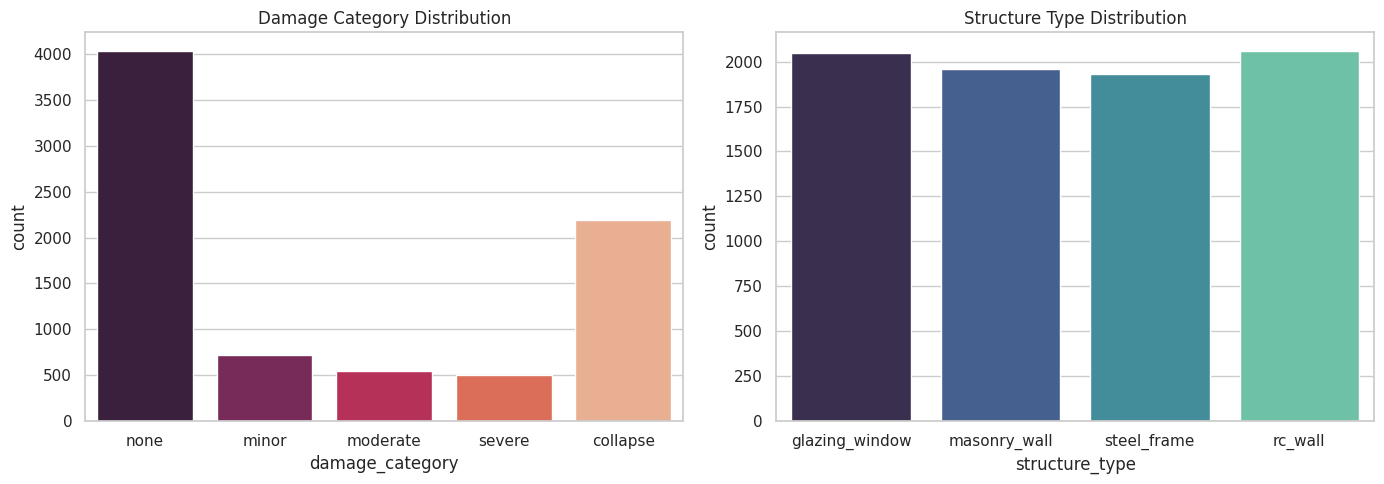

In [5]:
damage_order = ["none", "minor", "moderate", "severe", "collapse"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="damage_category", order=damage_order, ax=axes[0], palette="rocket")
axes[0].set_title("Damage Category Distribution")

sns.countplot(data=df, x="structure_type", ax=axes[1], palette="mako")
axes[1].set_title("Structure Type Distribution")

plt.tight_layout()
plt.show()

In [6]:
ct = pd.crosstab(df["structure_type"], df["damage_category"])
ct = ct[damage_order]
ct

damage_category,none,minor,moderate,severe,collapse
structure_type,,,,,
glazing_window,533,208,166,203,940
masonry_wall,1027,177,135,107,513
rc_wall,1356,143,115,85,361
steel_frame,1120,196,127,107,381


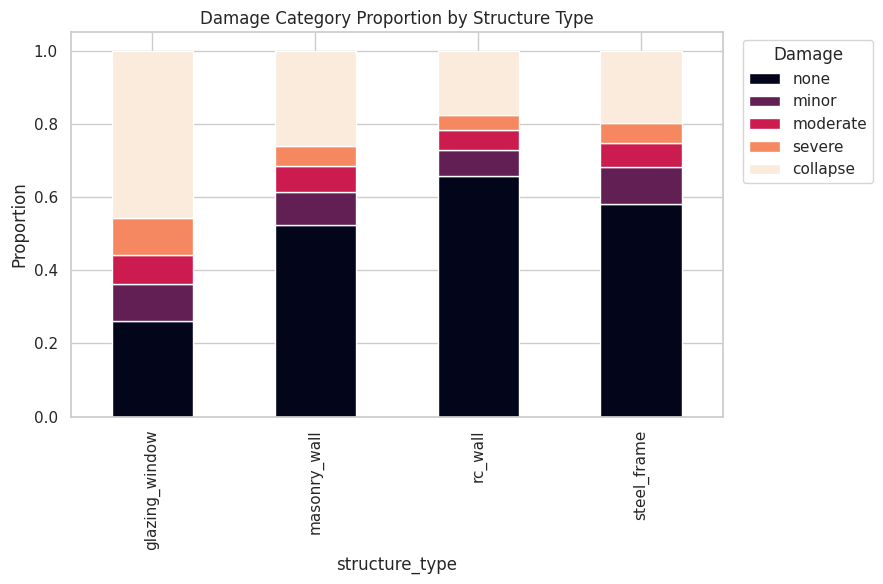

In [7]:
ct_norm = ct.div(ct.sum(axis=1), axis=0)

ct_norm.plot(kind="bar", stacked=True, figsize=(9, 6), colormap="rocket")
plt.title("Damage Category Proportion by Structure Type")
plt.ylabel("Proportion")
plt.legend(title="Damage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Note:** `none` and `collapse` dominate, `minor`/`moderate`/`severe` are rarer. Comes from log-uniform sampling of charge weight/distance - most random combos are either too weak to matter or clearly catastrophic. Need to account for this in modeling (class weights / stratified splits).

## 3. Numeric feature distributions

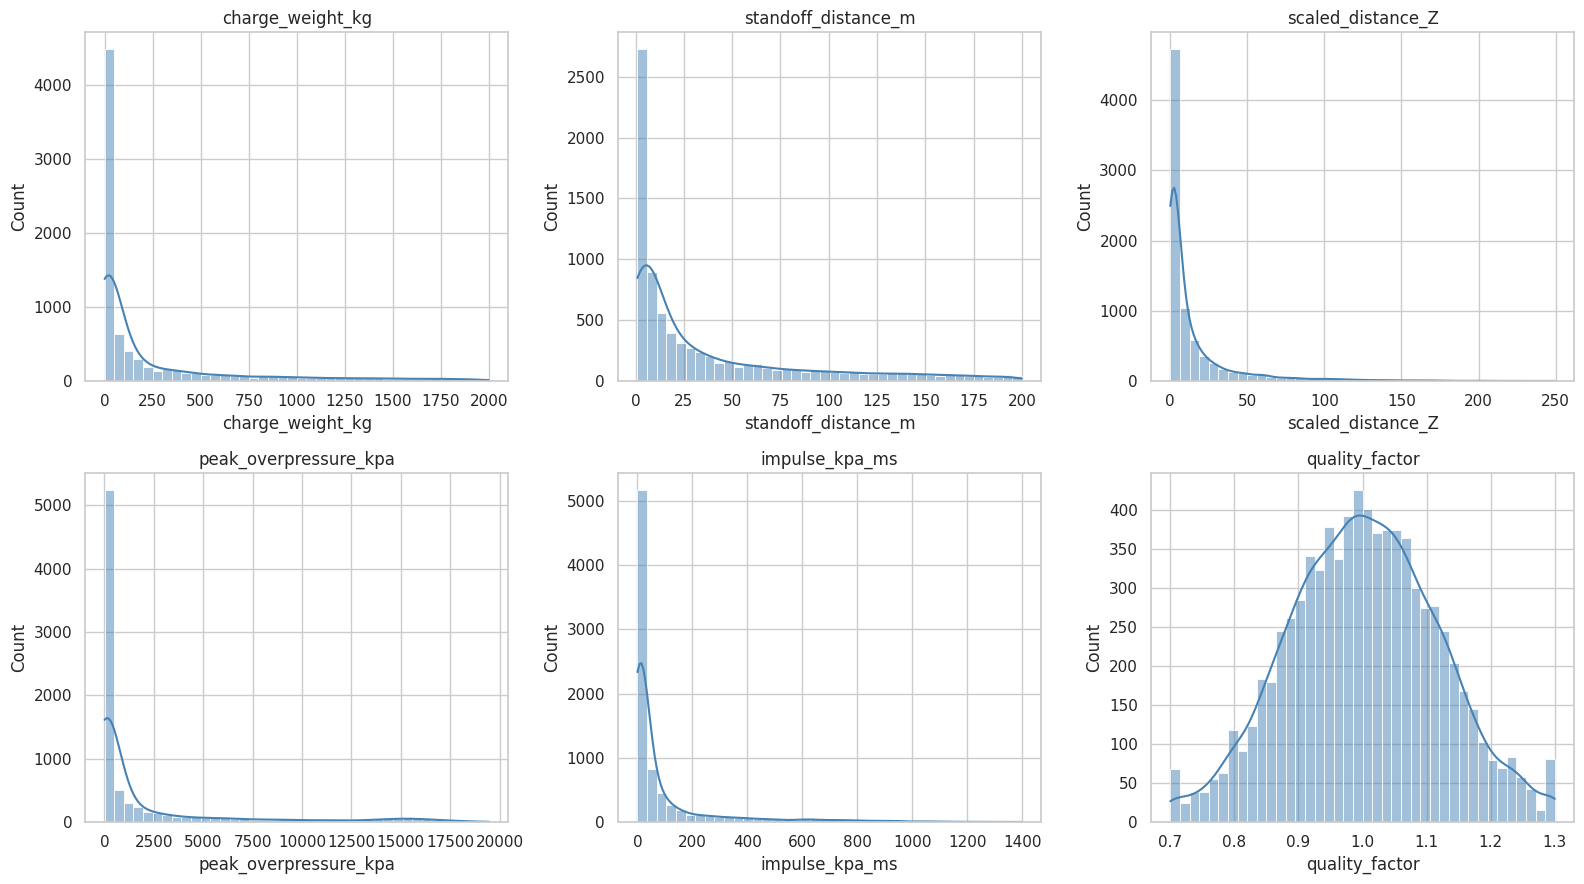

In [8]:
numeric_cols = ["charge_weight_kg", "standoff_distance_m", "scaled_distance_Z",
                "peak_overpressure_kpa", "impulse_kpa_ms", "quality_factor"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

All heavily right-skewed as expected from log-uniform sampling + power-law physics. Worth log-transforming before modeling.

## 4. Scaled distance vs damage

/tmp/ipykernel_575/3167753975.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="damage_category", y="scaled_distance_Z", order=damage_order,


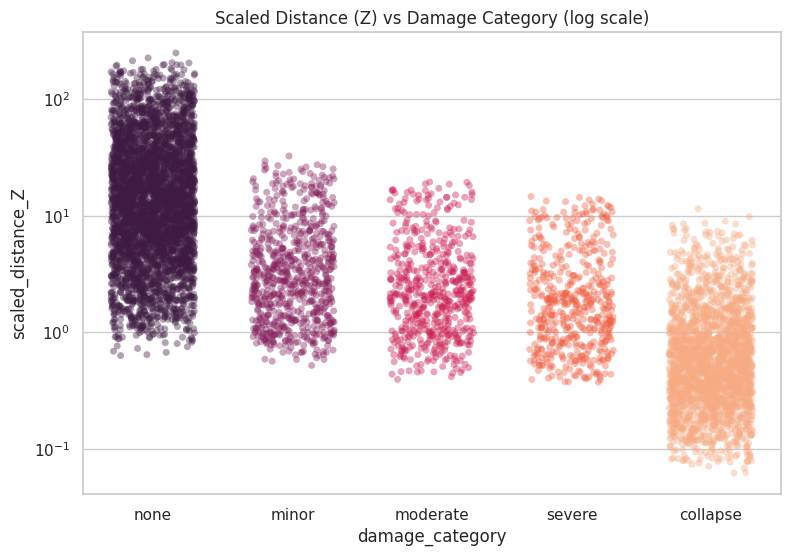

In [9]:
plt.figure(figsize=(9, 6))
sns.stripplot(data=df, x="damage_category", y="scaled_distance_Z", order=damage_order,
              jitter=0.3, alpha=0.4, palette="rocket")
plt.yscale("log")
plt.title("Scaled Distance (Z) vs Damage Category (log scale)")
plt.show()

Sanity check: smaller scaled distance (closer/bigger charge) should mean worse damage. Plot confirms this - collapse clusters at low Z, none at high Z.

## 5. Pressure-Impulse space, colored by damage

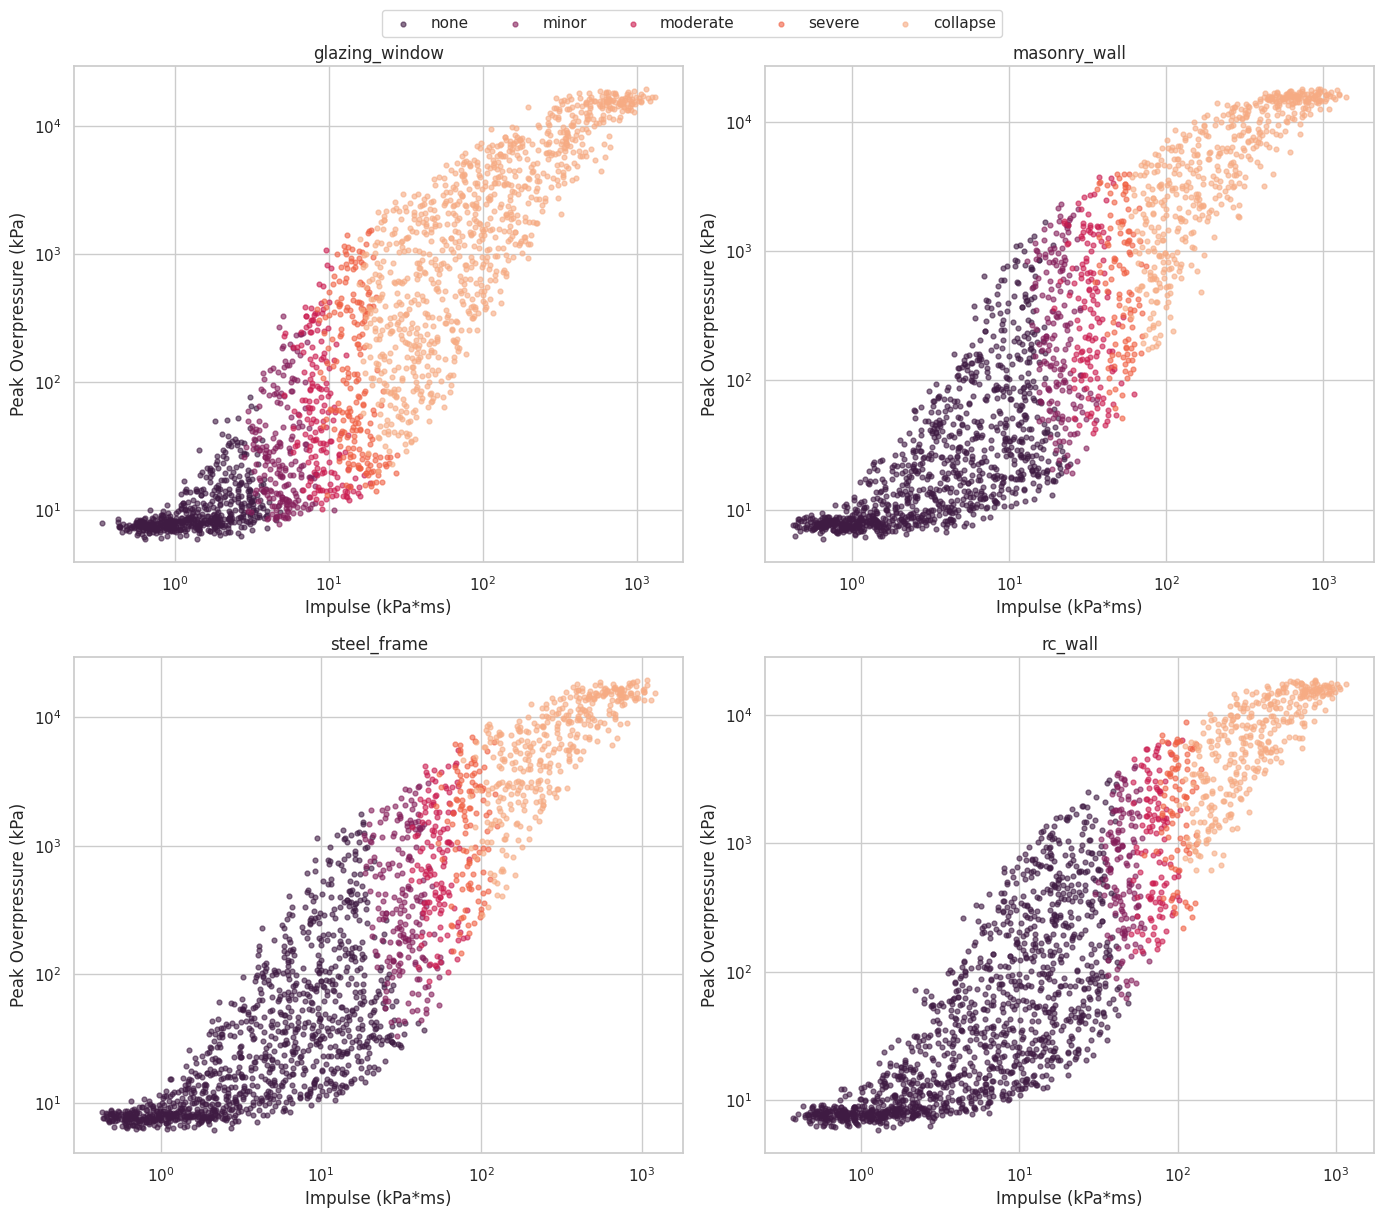

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
structure_types = df["structure_type"].unique()

palette = dict(zip(damage_order, sns.color_palette("rocket", len(damage_order))))

for ax, structure in zip(axes.flat, structure_types):
    sub = df[df["structure_type"] == structure]
    for damage in damage_order:
        pts = sub[sub["damage_category"] == damage]
        ax.scatter(pts["impulse_kpa_ms"], pts["peak_overpressure_kpa"],
                   s=12, alpha=0.6, label=damage, color=palette[damage])
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Impulse (kPa*ms)")
    ax.set_ylabel("Peak Overpressure (kPa)")
    ax.set_title(structure)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

Classic P-I diagram shape - nested bands from bottom-left (none) to top-right (collapse) per structure type. Confirms the labeling logic is physically reasonable.

## 6. Feature correlations

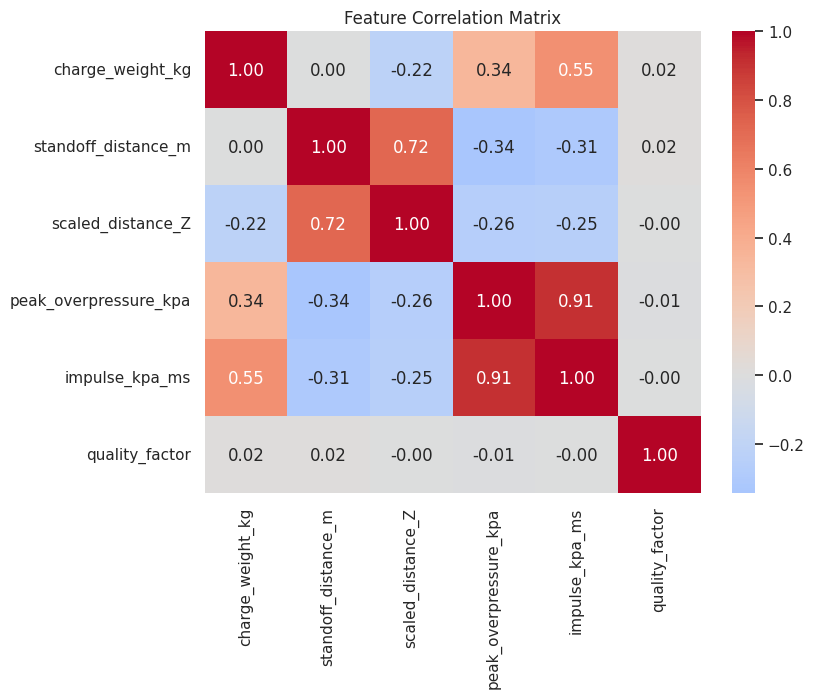

In [11]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

`charge_weight_kg` and `standoff_distance_m` feed into `scaled_distance_Z`, which drives overpressure/impulse - so those should correlate. `quality_factor` should be near-zero correlation with everything since it's independent noise.

## 7. Takeaways for modeling

- Class imbalance present - use class weights, stratified splits, look at per-class F1 not just accuracy
- `scaled_distance_Z` is the main physical driver - should be top feature importance
- Check performance per structure type, not just in aggregate
- Log-transform the skewed numeric features before modeling

Next: `02_model_training.ipynb`